In [4]:
import pandas as pd

# ---------------------------
# 1. Load marginal contributions
# ---------------------------
alloc = pd.read_csv("./logs/allocation_summary.csv")

# ---------------------------
# 2. Define site counts (rename to match CSV header)
# ---------------------------
site_counts = {
    1: 511,
    18: 382,
    4: 47,
    13: 35,
    21: 35,
    6: 34
}

counts_df = (
    pd.DataFrame(list(site_counts.items()), columns=["client", "Site_Count"])
)

# ---------------------------
# 3. Merge with allocation summary
# ---------------------------
merged = counts_df.merge(alloc, on="client", how="left")

# ---------------------------
# 4. Display
# ---------------------------
print(merged)


   client  Site_Count   shapley  least_core
0       1         511  0.177554    0.178211
1      18         382  0.133527    0.132618
2       4          47  0.135473    0.153893
3      13          35  0.138516    0.160683
4      21          35  0.069433    0.000000
5       6          34  0.135400    0.164500


In [12]:
import pandas as pd

# -------------------------------------------
# 1. Load coalition utilities CSV
# -------------------------------------------
coal = pd.read_csv("./logs/coalition_utilities.csv")

# -------------------------------------------
# 2. Define val metric columns and compute utility
# -------------------------------------------
val_cols = ["val_mean_dice", "val_tc", "val_wt", "val_et"]

# sanity check
for c in val_cols:
    if c not in coal.columns:
        raise ValueError(f"Expected column '{c}' not found in CSV. Got: {coal.columns}")
        
coal["utility"] = coal["val_mean_dice"]


# -------------------------------------------
# 3. Get top 5 and bottom 5 by utility
# -------------------------------------------
top5 = coal.nlargest(5, "utility").copy()
bottom5 = coal.nsmallest(5, "utility").copy()

top5["rank_group"] = "top_5"
bottom5["rank_group"] = "bottom_5"

# -------------------------------------------
# 4. Combine and display
# -------------------------------------------
summary_table = (
    pd.concat([top5, bottom5], axis=0)
    .sort_values("utility", ascending=False)
    .reset_index(drop=True)
)

summary_table


,coalition,size,val_mean_dice,val_tc,val_wt,val_et,utility,rank_group
0,"1,4,6,13,18,21",6,0.789905,0.733173,0.867730,0.798610,0.789905,top_5
1,"1,6,13,18",4,0.747481,0.691374,0.832806,0.747876,0.747481,top_5
2,"1,4,6,13,18",5,0.747339,0.691314,0.833803,0.746081,0.747339,top_5
3,"1,4,13,18",4,0.747218,0.692017,0.832299,0.746564,0.747218,top_5
4,"1,13,18",3,0.747117,0.691834,0.831083,0.748078,0.747117,top_5
5,"4,6,21",3,0.665740,0.591841,0.812136,0.611053,0.665740,bottom_5
6,"13,21",2,0.645032,0.584139,0.809338,0.549388,0.645032,bottom_5
7,"4,21",2,0.644050,0.581217,0.785336,0.578583,0.644050,bottom_5
8,"6,21",2,0.612145,0.518646,0.790677,0.541910,0.612145,bottom_5
9,21,1,0.443425,0.335756,0.667692,0.324938,0.443425,bottom_5


In [15]:
import pandas as pd

# -------------------------------------------
# 1. Load coalition utilities CSV
# -------------------------------------------
coal = pd.read_csv("./logs/coalition_utilities.csv")

# -------------------------------------------
# 2. Define val metric columns and compute utility
# -------------------------------------------
val_cols = ["val_mean_dice", "val_tc", "val_wt", "val_et"]

# sanity check
for c in val_cols:
    if c not in coal.columns:
        raise ValueError(f"Expected column '{c}' not found in CSV. Got: {coal.columns}")

# Use validation mean Dice as utility
coal["utility"] = coal["val_mean_dice"]

# -------------------------------------------
# 3. Compute global rank (including all coalitions)
# -------------------------------------------
coal = coal.sort_values("utility", ascending=False).reset_index(drop=True)
coal["global_rank"] = coal["utility"].rank(method="min", ascending=False).astype(int)

# -------------------------------------------
# 4. Filter out coalitions that include client 18
# -------------------------------------------
def contains_client(coalition_str, client_id=18):
    # coalition stored as "1,4,6,13,18,21" etc.
    members = [int(x) for x in str(coalition_str).split(",") if x.strip() != ""]
    return client_id in members

mask_no_18 = ~coal["coalition"].apply(contains_client)
coal_no_18 = coal[mask_no_18]

# -------------------------------------------
# 5. Take top 10 coalitions (without 18), but keep their global rank
# -------------------------------------------
top10_no_18 = (
    coal_no_18
    .sort_values("utility", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

# Optional: select/reorder columns for display
cols_to_show = [
    "global_rank",
    "coalition",
    "size",
    "utility",
    "val_mean_dice",
    "val_tc",
    "val_wt",
    "val_et",
]
top10_no_18[cols_to_show]


,global_rank,coalition,size,utility,val_mean_dice,val_tc,val_wt,val_et
0,17,"1,4,6,13,21",5,0.738164,0.738164,0.686723,0.821976,0.734674
1,18,"1,4,6,13",4,0.738038,0.738038,0.686960,0.820628,0.735660
2,19,"1,4,6,21",4,0.736032,0.736032,0.684669,0.816446,0.736793
3,20,"1,4,6",3,0.735199,0.735199,0.683963,0.814131,0.737697
4,21,"1,4,13,21",4,0.734800,0.734800,0.684926,0.816660,0.731751
5,22,"1,6,13,21",4,0.734314,0.734314,0.683022,0.816794,0.732382
6,23,"1,4,13",3,0.733881,0.733881,0.684428,0.814359,0.732082
7,24,"1,6,13",3,0.733054,0.733054,0.681935,0.814213,0.732598
8,25,"1,4,21",3,0.731822,0.731822,0.682041,0.809880,0.733507
9,26,"1,6,21",3,0.730959,0.730959,0.679459,0.809716,0.734089


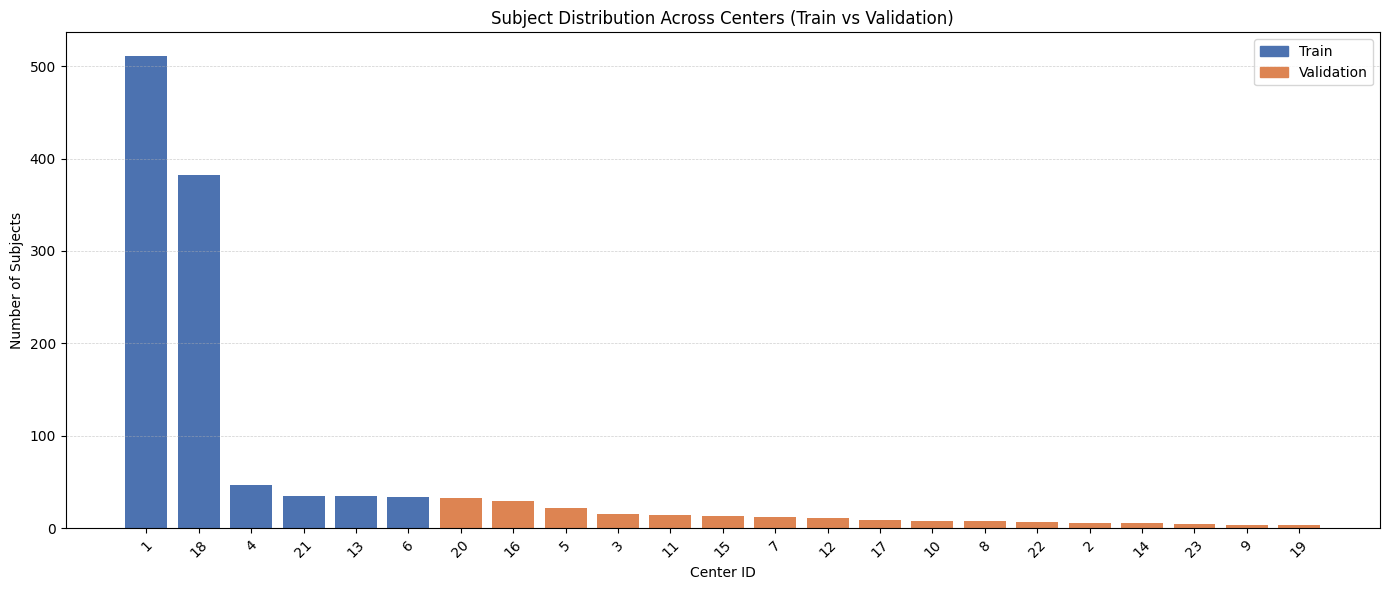

Saved figure to ./logs/center_distribution.pdf


In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# -------------------------
# 1. Define subject counts
# -------------------------
train_centers = {
    1: 511,
    4: 47,
    6: 34,
    13: 35,
    18: 382,
    21: 35,
}

val_centers = {
    2: 6,
    3: 15,
    5: 22,
    7: 12,
    8: 8,
    9: 4,
    10: 8,
    11: 14,
    12: 11,
    14: 6,
    15: 13,
    16: 30,
    17: 9,
    19: 4,
    20: 33,
    22: 7,
    23: 5,
}

# Convert to DataFrame
df_train = pd.DataFrame({
    "Center": list(train_centers.keys()),
    "Subjects": list(train_centers.values()),
    "Split": "Train"
})

df_val = pd.DataFrame({
    "Center": list(val_centers.keys()),
    "Subjects": list(val_centers.values()),
    "Split": "Validation"
})

df = pd.concat([df_train, df_val], axis=0)

# Sort by subject count
df = df.sort_values("Subjects", ascending=False).reset_index(drop=True)

# -------------------------
# 2. Plot
# -------------------------
plt.figure(figsize=(14, 6))

colors = df["Split"].map({"Train": "#4C72B0", "Validation": "#DD8452"})

plt.bar(df["Center"].astype(str), df["Subjects"], color=colors)

plt.xlabel("Center ID")
plt.ylabel("Number of Subjects")
plt.title("Subject Distribution Across Centers (Train vs Validation)")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.6)

# Legend
train_patch = plt.Rectangle((0,0),1,1, color="#4C72B0", label="Train")
val_patch   = plt.Rectangle((0,0),1,1, color="#DD8452", label="Validation")
plt.legend(handles=[train_patch, val_patch])

plt.tight_layout()

# -------------------------
# 3. Save as PDF
# -------------------------
os.makedirs("./logs", exist_ok=True)
pdf_path = "./logs/center_distribution.pdf"
plt.savefig(pdf_path, format="pdf", bbox_inches="tight")

plt.show()

print(f"Saved figure to {pdf_path}")


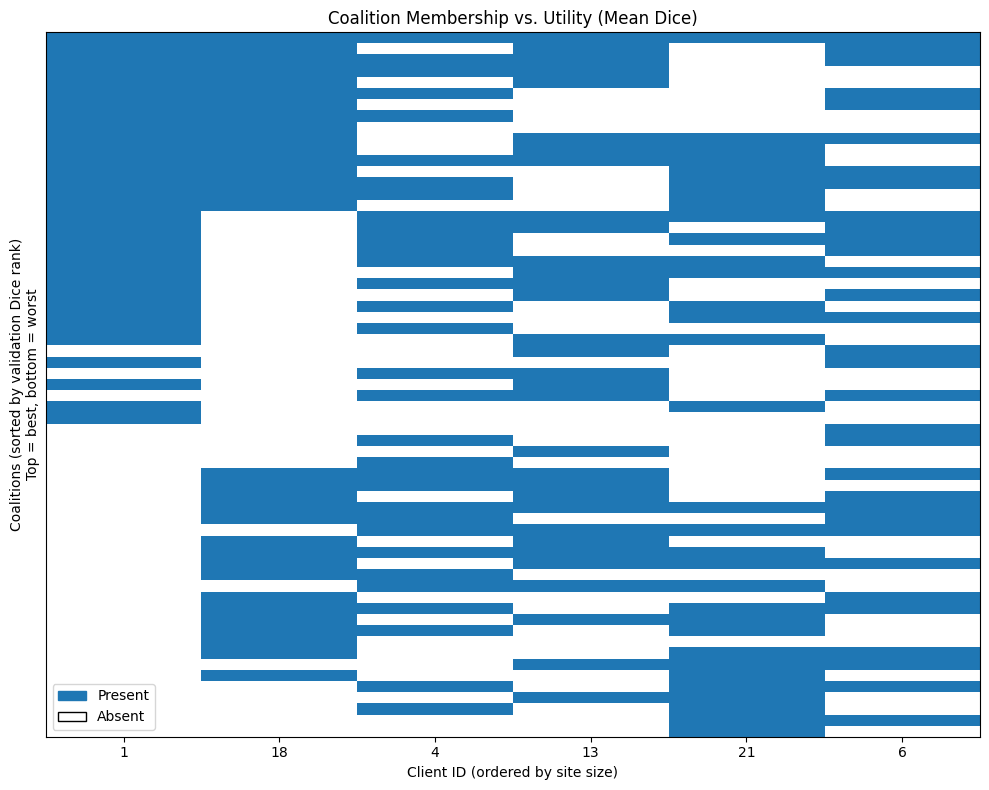

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

# Load coalition utilities
coal = pd.read_csv("./logs/coalition_utilities.csv")

# Utility = val_mean_dice
coal["utility"] = coal["val_mean_dice"]

# Sort coalitions by utility (best at top)
coal = coal.sort_values("utility", ascending=False).reset_index(drop=True)
coal["rank"] = coal.index + 1  # 1 = best coalition

# Client order (by site size)
ordered_clients = [1, 18, 4, 13, 21, 6]

# Build indicator matrix
indicator = np.zeros((len(coal), len(ordered_clients)))
for i, c in enumerate(coal["coalition"]):
    members = [int(x) for x in c.split(",")]
    for m in members:
        if m in ordered_clients:
            indicator[i, ordered_clients.index(m)] = 1

indicator_df = pd.DataFrame(indicator, columns=ordered_clients)

# Discrete colormap
cmap = ListedColormap(["white", "#1f77b4"])
norm = BoundaryNorm([0, 0.5, 1], cmap.N)

plt.figure(figsize=(10, 8))
plt.imshow(indicator_df.values, aspect="auto", cmap=cmap, norm=norm)

# Axes
plt.xticks(range(len(ordered_clients)), ordered_clients)
plt.xlabel("Client ID (ordered by site size)")
plt.yticks([])
plt.ylabel("Coalitions (sorted by validation Dice rank)\nTop = best, bottom = worst")
plt.title("Coalition Membership vs. Utility (Mean Dice)")

# -------------------------
# Legend (bottom left)
# -------------------------
present_patch = plt.Rectangle((0,0),1,1, color="#1f77b4", label="Present")
absent_patch  = plt.Rectangle((0,0),1,1, edgecolor="black", facecolor="white", label="Absent")

plt.legend(handles=[present_patch, absent_patch],
           loc="lower left",
           frameon=True)

plt.tight_layout()
plt.show()
